# Brand Compliance Evaluation — Waadaa Ground Truth

Evaluates the full BrandGuard pipeline against 30 labeled images (5 Graphic folders × 1 Approved + 5 Rejected).

**Metrics:** Verdict accuracy · Per-dimension precision/recall · Reasoning quality · Latency p50/p95/p99 · Token usage · Cost per image

**Modes:**
- **No-RAG** (default): `BRAND_ID = None` — uses YAML defaults, no Qdrant needed
- **RAG**: Run Section 2 to index the Waadaa PDF, then set `BRAND_ID` accordingly

## Section 0 — Configuration

In [3]:
import os, sys, time, json, re
from pathlib import Path
from dotenv import load_dotenv

# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath(""))           # consolidated_pipeline/notebooks/
REPO_ROOT    = NOTEBOOK_DIR.parent                 # consolidated_pipeline/
SAMPLES_DIR  = Path("/Users/sayems_mac/BrandReview/brandReviewModels/Training Samples")
PDF_PATH     = SAMPLES_DIR / "Brand Review-Training content-Waadaa.pdf"

# Add src to path for direct imports
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Load .env from consolidated_pipeline/ (contains MONGO_URI, OPENROUTER_API_KEY, etc.)
load_dotenv(REPO_ROOT / ".env")

# ── Brand ID ───────────────────────────────────────────────────────────────
# MUST be non-None — forces the OpenRouter LLM judge path (skips vLLM fallbacks).
# Run Section 2 once to create the Waadaa brand profile in MongoDB and get the ID.
# After first run, paste the printed ID here to reuse it.
BRAND_ID: str | None = '69d190a9d28fbf402ee7f7ab'   # ← Set to the ID printed by Section 2 after first run

# ── Model pricing (per 1M tokens, USD) ─────────────────────────────────────
MODEL_PRICING = {
    "input_per_1m":  15.00,   # claude-opus-4-6 input
    "output_per_1m": 75.00,   # claude-opus-4-6 output
}

# ── Pass threshold ──────────────────────────────────────────────────────────
PASS_THRESHOLD = 0.88

print(f"Repo root   : {REPO_ROOT}")
print(f"Samples dir : {SAMPLES_DIR}")
print(f"MONGO_URI   : {'set' if os.environ.get('MONGO_URI') else 'NOT SET'}")
print(f"OPENROUTER  : {'set (' + os.environ.get('OPENROUTER_API_KEY','')[:8] + '...)' if os.environ.get('OPENROUTER_API_KEY') else 'NOT SET'}")
print(f"BRAND_ID    : {BRAND_ID or '⚠ Not set — run Section 2 first!'}")

Repo root   : /Users/sayems_mac/BrandReview/brandReviewModels/consolidated_pipeline
Samples dir : /Users/sayems_mac/BrandReview/brandReviewModels/Training Samples
MONGO_URI   : set
OPENROUTER  : NOT SET
BRAND_ID    : 69d190a9d28fbf402ee7f7ab


## Section 1 — Ground Truth (from Waadaa PDF)

In [22]:
# Dimension keyword sets used for reasoning quality scoring
DIM_KEYWORDS = {
    "color":      ["color", "colour", "palette", "background", "hue", "shade", "#"],
    "logo":       ["logo", "position", "placement", "size", "corner", "height", "top-right", "top right"],
    "typography": ["font", "typography", "typeface", "bangla", "english", "shorif", "neo sans"],
}

# Ground truth: image_path → {expected_verdict, dims, reason_note}
# Derived from: Brand Review-Training content-Waadaa.pdf
GROUND_TRUTH = {
    # ── Graphic 1 ──────────────────────────────────────────────────────────
    "Graphic 1/Approved.jpg":    {"verdict": "approved", "dims": []},
    "Graphic 1/Rejected 1.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Colorful logo on dark background"},
    "Graphic 1/Rejected 2.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong Bangla font"},
    "Graphic 1/Rejected 3.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong English font"},
    "Graphic 1/Rejected 4.jpg":  {"verdict": "rejected", "dims": ["color"],                    "note": "Wrong brand color"},
    "Graphic 1/Rejected 5.jpg":  {"verdict": "rejected", "dims": ["typography","logo","color"],"note": "Wrong fonts, colorful logo on dark, wrong color"},
    # ── Graphic 2 ──────────────────────────────────────────────────────────
    "Graphic 2/Approved.jpg":    {"verdict": "approved", "dims": []},
    "Graphic 2/Rejected 1.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong English font"},
    "Graphic 2/Rejected 2.jpg":  {"verdict": "rejected", "dims": ["color"],                    "note": "Wrong brand color"},
    "Graphic 2/Rejected 3.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Wrong logo placement"},
    "Graphic 2/Rejected 4.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Wrong logo size"},
    "Graphic 2/Rejected 5.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Wrong logo color"},
    # ── Graphic 3 ──────────────────────────────────────────────────────────
    "Graphic 3/Approved.jpg":    {"verdict": "approved", "dims": []},
    "Graphic 3/Rejected 1.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong English font"},
    "Graphic 3/Rejected 2.jpg":  {"verdict": "rejected", "dims": ["color","typography"],       "note": "Wrong brand color, wrong Bangla+English font"},
    "Graphic 3/Rejected 3.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong font size, wrong background"},
    "Graphic 3/Rejected 4.jpg":  {"verdict": "rejected", "dims": ["logo","typography"],        "note": "Wrong logo placement, wrong Bangla font"},
    "Graphic 3/Rejected 5.jpg":  {"verdict": "rejected", "dims": ["color","typography","logo"],"note": "Wrong color, wrong fonts, wrong logo size"},
    # ── Graphic 4 ──────────────────────────────────────────────────────────
    "Graphic 4/Approved.jpg":    {"verdict": "approved", "dims": []},
    "Graphic 4/Rejected 1.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Wrong logo position"},
    "Graphic 4/Rejected 2.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong Bangla font"},
    "Graphic 4/Rejected 3.jpg":  {"verdict": "rejected", "dims": ["color"],                    "note": "Wrong background color"},
    "Graphic 4/Rejected 4.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Wrong logo size"},
    "Graphic 4/Rejected 5.jpg":  {"verdict": "rejected", "dims": ["logo","color"],             "note": "Wrong logo color, wrong brand color"},
    # ── Graphic 5 ──────────────────────────────────────────────────────────
    "Graphic 5/Approved.jpg":    {"verdict": "approved", "dims": []},
    "Graphic 5/Rejected 1.jpg":  {"verdict": "rejected", "dims": ["typography"],               "note": "Wrong English font"},
    "Graphic 5/Rejected 2.jpg":  {"verdict": "rejected", "dims": ["logo"],                    "note": "Wrong logo position"},
    "Graphic 5/Rejected 3.jpg":  {"verdict": "rejected", "dims": ["color"],                    "note": "Wrong brand color"},
    "Graphic 5/Rejected 4.jpg":  {"verdict": "rejected", "dims": ["color","typography"],       "note": "Wrong brand color, wrong font"},
    "Graphic 5/Rejected 5.jpg":  {"verdict": "rejected", "dims": ["color","logo"],             "note": "Wrong background color, wrong logo color"},
}

# Resolve to absolute paths and verify files exist
missing = []
resolved = {}
for rel, gt in GROUND_TRUTH.items():
    p = SAMPLES_DIR / rel
    if p.exists():
        resolved[str(p)] = gt
    else:
        missing.append(str(p))

print(f"Ground truth entries : {len(GROUND_TRUTH)}")
print(f"Files found          : {len(resolved)}")
if missing:
    print(f"Missing ({len(missing)}):\n  " + "\n  ".join(missing))

Ground truth entries : 30
Files found          : 30


## Section 2 — [Optional] RAG Setup

Skip this cell if `BRAND_ID = None`. Run it once to index the Waadaa PDF into Qdrant + MongoDB and get a `brand_id`.

In [16]:
# Section 2 — Create Waadaa brand profile in MongoDB
# Run this ONCE. Copy the printed brand_id into BRAND_ID in Section 0, then skip this cell.

from brandguard.brand_profile.brand_store import BrandStore

WAADAA_RULES = {
    "color_rules": {
        "palette":     ["#000080", "#4b0082", "#63c6ff"],
        "gradient":    "#000080 to #4b0082",
        "forbidden":   [],
        "raw_description": "Primary: #000080 (navy), #4b0082 (purple), #63c6ff (light blue). Gradient: #000080 → #4b0082.",
    },
    "typography_rules": {
        "bangla_font":   "Shorif Sandwip",
        "english_font":  "Neo Sans",
        "approved_fonts": ["Shorif Sandwip", "Neo Sans"],
        "forbidden_fonts": [],
        "raw_description": "Bangla font must be Shorif Sandwip. English font must be Neo Sans.",
    },
    "logo_rules": {
        "position":             "top-right",
        "min_height_px":        85,
        "dark_bg_use_white":    True,
        "colorful_on_white_only": True,
        "allowed_zones":        ["top-right"],
        "raw_description": (
            "Logo must always be in the top-right corner. "
            "Use the white version on dark/colored backgrounds. "
            "Use the colorful version on white backgrounds only. "
            "Minimum logo height: 85px."
        ),
    },
    "brand_voice_rules": {
        "tone":     "professional",
        "language": "Bangla/English bilingual",
        "raw_description": "Professional tone. Bilingual (Bangla and English). No slang.",
    },
}

store = BrandStore()
brand_id = store.create(brand_name="waadaa_eval")
store.update(brand_id, {"rules": WAADAA_RULES})

print(f"✓ Waadaa brand profile created in MongoDB.")
print(f"  brand_id = '{brand_id}'")
print()
print("  → Paste this brand_id into BRAND_ID in Section 0, then re-run from Section 0.")

✓ Waadaa brand profile created in MongoDB.
  brand_id = '85030e3b-4ec0-454a-81cb-ca4399b2e4e6'

  → Paste this brand_id into BRAND_ID in Section 0, then re-run from Section 0.


## Section 3 — Pipeline Setup

In [23]:
from brandguard.core.pipeline_orchestrator_new import PipelineOrchestrator
from brandguard.config.settings import Settings

settings = Settings()
orchestrator = PipelineOrchestrator(settings)

# Verify API key
api_key = os.environ.get("OPENROUTER_API_KEY", "")
model   = os.environ.get("OPENROUTER_MODEL", "anthropic/claude-opus-4-6")
print(f"API key   : {'set (' + api_key[:8] + '...)' if api_key else 'NOT SET — LLM judge will be skipped'}")
print(f"Model     : {model}")
print(f"Orchestrator ready: {type(orchestrator).__name__}")

🚀 Starting import_all_models...
✅ ColorPaletteExtractor and ColorPaletteValidator imported successfully using importlib
✅ FontIdentifier imported successfully using importlib
✅ TypographyValidator imported successfully using importlib
❌ FontComplianceChecker import failed: No module named 'paddleocr'
❌ TextExtractor import failed: No module named 'paddleocr'
✅ VLLMToneAnalyzer imported successfully using importlib
✅ HybridToneAnalyzer imported successfully using importlib
❌ AgenticLogoDetector import failed: No module named 'brandguard.core.agentic_detector'
✅ LogoDetector imported successfully using importlib
✅ LogoPlacementValidator imported successfully using importlib
✅ PDFImageExtractor and PDFLogoDetector imported successfully using importlib


vLLM connection test failed: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /v1/chat/completions (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x12aae4ed0>: Failed to establish a new connection: [Errno 61] Connection refused'))
⚠️ Qwen API connection failed - will use dummy fallback
⚠️ FontComplianceChecker not available, using fallback


✅ YOLOS logo detection model loaded: ellabettison/Logo-Detection-finetune
✅ Qwen2.5-VL-3B-Instruct configured: Qwen/Qwen2.5-VL-3B-Instruct
API key   : set (sk-or-v1...)
Model     : anthropic/claude-opus-4-6
Orchestrator ready: PipelineOrchestrator


## Section 4 — Test Runner

In [24]:
import traceback as _tb

results = []

total = len(resolved)
for idx, (image_path, gt) in enumerate(resolved.items(), 1):
    rel_name = Path(image_path).relative_to(SAMPLES_DIR)
    print(f"[{idx:02d}/{total}] {rel_name} ... ", end="", flush=True)

    t0 = time.perf_counter()
    try:
        analysis = orchestrator.analyze_content(
            input_source=image_path,
            source_type="image",
            brand_id=BRAND_ID,
            analysis_options={"pass_threshold": PASS_THRESHOLD},
        )
        latency_s = time.perf_counter() - t0
        error = analysis.get("error")  # orchestrator returns {'error': ...} on internal failure
    except Exception as e:
        latency_s = time.perf_counter() - t0
        analysis = {}
        error = str(e)
        print(f"\n[TRACEBACK]\n{_tb.format_exc()}")

    # If orchestrator returned an error dict, show the first traceback only (avoid spam)
    if error and idx == 1:
        print(f"\n  ⚠ Internal error: {error}")

    # Pull token usage from judge (set by brand_compliance_judge.py after each call)
    usage = {}
    try:
        usage = orchestrator.brand_judge.last_usage
    except AttributeError:
        pass

    predicted_verdict = (analysis.get("verdict") or "").lower()
    breakdown = analysis.get("compliance_breakdown") or analysis.get("complianceBreakdown") or {}

    # Which dimensions did the model flag as failed?
    flagged_dims = [
        dim for dim, data in breakdown.items()
        if isinstance(data, dict) and not data.get("passed", True)
    ]

    # Reasoning quality: does the verdict_reason + per-dim reasons mention the expected keywords?
    full_reason_text = " ".join([
        (analysis.get("verdict_reason") or ""),
        " ".join(
            str(data.get("reason", ""))
            for data in breakdown.values()
            if isinstance(data, dict)
        ),
    ]).lower()

    reasoning_scores = {}
    for dim in gt["dims"]:
        keywords = DIM_KEYWORDS.get(dim, [dim])
        reasoning_scores[dim] = int(any(kw in full_reason_text for kw in keywords))
    reasoning_quality = (
        sum(reasoning_scores.values()) / len(reasoning_scores)
        if reasoning_scores else 1.0   # approved images: no dims to check
    )

    # Cost calculation
    input_tokens  = usage.get("prompt_tokens", 0)
    output_tokens = usage.get("completion_tokens", 0)
    total_tokens  = usage.get("total_tokens", input_tokens + output_tokens)
    cost_usd = (
        input_tokens  / 1_000_000 * MODEL_PRICING["input_per_1m"] +
        output_tokens / 1_000_000 * MODEL_PRICING["output_per_1m"]
    )

    verdict_correct = (predicted_verdict == gt["verdict"])
    status = "✓" if verdict_correct else "✗"
    print(f"{status}  predicted={predicted_verdict or 'N/A'}  latency={latency_s:.1f}s  tokens={total_tokens}  cost=${cost_usd:.4f}")

    results.append({
        "image":             str(rel_name),
        "expected_verdict":  gt["verdict"],
        "predicted_verdict": predicted_verdict,
        "verdict_correct":   verdict_correct,
        "expected_dims":     gt["dims"],
        "flagged_dims":      flagged_dims,
        "reasoning_scores":  reasoning_scores,
        "reasoning_quality": reasoning_quality,
        "latency_s":         round(latency_s, 3),
        "input_tokens":      input_tokens,
        "output_tokens":     output_tokens,
        "total_tokens":      total_tokens,
        "cost_usd":          round(cost_usd, 6),
        "overall_score":     analysis.get("overall_compliance", None),
        "error":             error,
        "note":              gt.get("note", ""),
    })

    # Stop after first image to inspect error before running all 30
    if error and idx == 1:
        print("\n  ⛔ Stopping after first error — fix and re-run.")
        break

print(f"\nDone. {len(results)} images evaluated.")

[01/30] Graphic 1/Approved.jpg ... 🔍 Step 1: Trying custom YOLO logo detection...
✅ YOLO detections: 5 found
✅ Custom YOLO model found detections - using YOLO results
Logo analysis summary: 5 detection(s)
Color results: [{'rgb': (53, 0, 129), 'hex': '#350081', 'percentage': 42.28, 'cluster_id': 0}, {'rgb': (21, 0, 128), 'hex': '#150080', 'percentage': 36.95, 'cluster_id': 3}, {'rgb': (37, 207, 249), 'hex': '#25cff9', 'percentage': 6.44, 'cluster_id': 2}, {'rgb': (249, 247, 246), 'hex': '#f9f7f6', 'percentage': 4.45, 'cluster_id': 5}, {'rgb': (179, 241, 252), 'hex': '#b3f1fc', 'percentage': 4.1, 'cluster_id': 1}, {'rgb': (49, 74, 88), 'hex': '#314a58', 'percentage': 3.37, 'cluster_id': 4}, {'rgb': (35, 133, 165), 'hex': '#2385a5', 'percentage': 1.68, 'cluster_id': 6}, {'rgb': (32, 0, 216), 'hex': '#2000d8', 'percentage': 0.73, 'cluster_id': 7}]


/Users/sayems_mac/BrandReview/brandReviewModels/.venv/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✓  predicted=approved  latency=38.3s  tokens=5628  cost=$0.1585
[02/30] Graphic 1/Rejected 1.jpg ... 🔍 Step 1: Trying custom YOLO logo detection...
✅ YOLO detections: 3 found
✅ Custom YOLO model found detections - using YOLO results
Logo analysis summary: 3 detection(s)
Color results: [{'rgb': (53, 0, 129), 'hex': '#350081', 'percentage': 42.38, 'cluster_id': 4}, {'rgb': (21, 0, 128), 'hex': '#150080', 'percentage': 37.01, 'cluster_id': 0}, {'rgb': (37, 207, 249), 'hex': '#25cff9', 'percentage': 6.44, 'cluster_id': 2}, {'rgb': (249, 246, 246), 'hex': '#f9f6f6', 'percentage': 4.31, 'cluster_id': 6}, {'rgb': (179, 241, 252), 'hex': '#b3f1fc', 'percentage': 4.08, 'cluster_id': 1}, {'rgb': (49, 74, 88), 'hex': '#314a58', 'percentage': 3.37, 'cluster_id': 3}, {'rgb': (34, 134, 165), 'hex': '#2286a5', 'percentage': 1.67, 'cluster_id': 5}, {'rgb': (32, 0, 216), 'hex': '#2000d8', 'percentage': 0.73, 'cluster_id': 7}]
✓  predicted=rejected  latency=26.2s  tokens=5225  cost=$0.1383
[03/30] Graph

In [8]:
import json as _json
from pathlib import Path as _Path

_results_path = _Path("results.json")
with open(_results_path, "w") as _f:
    _json.dump(results, _f, indent=2, default=str)
print(f"✓ Saved {len(results)} results → {_results_path.resolve()}")

✓ Saved 8 results → /Users/sayems_mac/BrandReview/brandReviewModels/consolidated_pipeline/notebooks/results.json


## Section 5 — Accuracy Report

══════════════════════════════════════════════════
 OVERALL ACCURACY : 86.7%  (26/30)
 False positive   : 40.0%  (approved → incorrectly rejected)
 False negative   : 8.0%  (rejected → incorrectly approved)
══════════════════════════════════════════════════


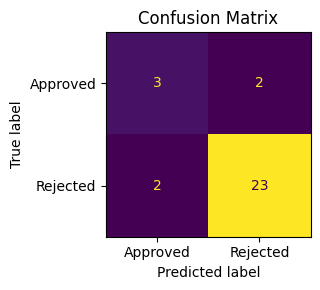


Per-Dimension Precision / Recall


,TP,FP,FN,Precision,Recall,F1
Dimension,,,,,,
color,9,10,1,47.4%,90.0%,62.1%
logo,7,2,5,77.8%,58.3%,66.7%
typography,10,9,2,52.6%,83.3%,64.5%



Reasoning quality (avg across 25 rejected images): 100.0%
  = fraction of expected rejection dimensions mentioned in the model's reasons


In [25]:
import pandas as pd
import numpy as np

df = pd.DataFrame(results)

# ── Overall accuracy ────────────────────────────────────────────────────────
total       = len(df)
correct     = df["verdict_correct"].sum()
accuracy    = correct / total

approved_df = df[df["expected_verdict"] == "approved"]
rejected_df = df[df["expected_verdict"] == "rejected"]

fpr = (~approved_df["verdict_correct"]).sum() / max(len(approved_df), 1)  # false positive rate
fnr = (~rejected_df["verdict_correct"]).sum() / max(len(rejected_df), 1)  # false negative rate

print("═" * 50)
print(f" OVERALL ACCURACY : {accuracy:.1%}  ({correct}/{total})")
print(f" False positive   : {fpr:.1%}  (approved → incorrectly rejected)")
print(f" False negative   : {fnr:.1%}  (rejected → incorrectly approved)")
print("═" * 50)

# ── Confusion matrix ────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = (df["expected_verdict"] == "rejected").astype(int)
y_pred = (df["predicted_verdict"] == "rejected").astype(int)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=["Approved", "Rejected"]).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Per-dimension precision / recall ───────────────────────────────────────
all_dims = ["color", "logo", "typography"]
dim_stats = []
for dim in all_dims:
    expected_positive = [r for r in results if dim in r["expected_dims"]]
    flagged_positive  = [r for r in results if dim in r["flagged_dims"]]
    tp = sum(1 for r in expected_positive if dim in r["flagged_dims"])
    fp = sum(1 for r in flagged_positive  if dim not in r["expected_dims"])
    fn = len(expected_positive) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float("nan")
    dim_stats.append({"Dimension": dim, "TP": tp, "FP": fp, "FN": fn,
                      "Precision": f"{precision:.1%}", "Recall": f"{recall:.1%}", "F1": f"{f1:.1%}"})

print("\nPer-Dimension Precision / Recall")
display(pd.DataFrame(dim_stats).set_index("Dimension"))

# ── Reasoning quality ───────────────────────────────────────────────────────
rej_with_dims = [r for r in results if r["expected_verdict"] == "rejected" and r["expected_dims"]]
avg_rq = np.mean([r["reasoning_quality"] for r in rej_with_dims]) if rej_with_dims else float("nan")
print(f"\nReasoning quality (avg across {len(rej_with_dims)} rejected images): {avg_rq:.1%}")
print("  = fraction of expected rejection dimensions mentioned in the model's reasons")

## Section 6 — Latency Report

Latency (seconds)
──────────────────────────────
  Min   : 23.22s
  p50   : 30.42s
  p95   : 36.72s
  p99   : 37.93s
  Max   : 38.26s
  Mean  : 30.22s


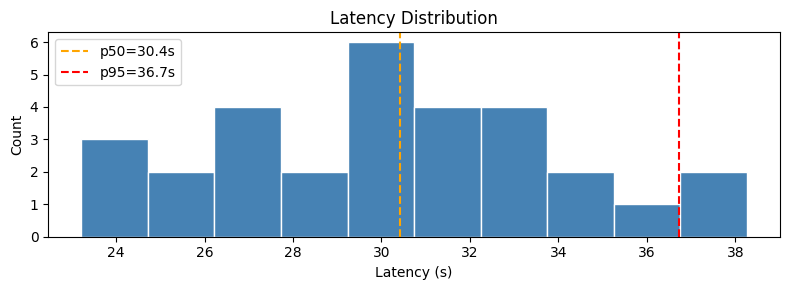

In [26]:
import matplotlib.pyplot as plt
import numpy as np

latencies = df["latency_s"].values

stats = {
    "Min":  np.min(latencies),
    "p50":  np.percentile(latencies, 50),
    "p95":  np.percentile(latencies, 95),
    "p99":  np.percentile(latencies, 99),
    "Max":  np.max(latencies),
    "Mean": np.mean(latencies),
}

print("Latency (seconds)")
print("─" * 30)
for k, v in stats.items():
    print(f"  {k:<6}: {v:.2f}s")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(latencies, bins=10, color="steelblue", edgecolor="white")
for label, val in [("p50", stats["p50"]), ("p95", stats["p95"])]:
    ax.axvline(val, color="red" if label == "p95" else "orange", linestyle="--", label=f"{label}={val:.1f}s")
ax.set_xlabel("Latency (s)")
ax.set_ylabel("Count")
ax.set_title("Latency Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Section 7 — Token & Cost Report

Token & Cost Summary
────────────────────────────────────────
  Total input tokens  : 134,656
  Total output tokens : 39,566
  Total tokens        : 174,222
  Total cost (USD)    : $4.9873
  Avg cost / image    : $0.1662


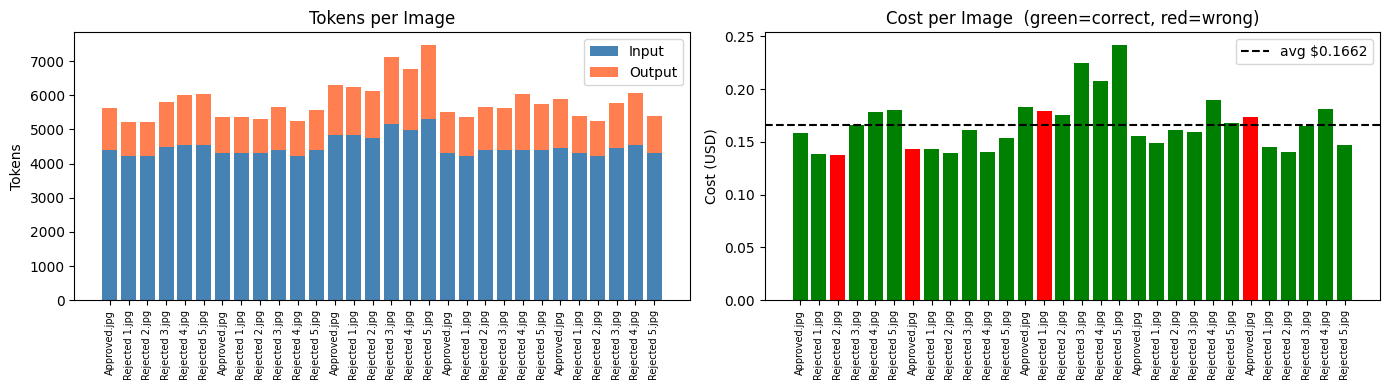

In [27]:
total_input  = df["input_tokens"].sum()
total_output = df["output_tokens"].sum()
total_toks   = df["total_tokens"].sum()
total_cost   = df["cost_usd"].sum()
avg_cost     = total_cost / len(df)

print("Token & Cost Summary")
print("─" * 40)
print(f"  Total input tokens  : {total_input:,}")
print(f"  Total output tokens : {total_output:,}")
print(f"  Total tokens        : {total_toks:,}")
print(f"  Total cost (USD)    : ${total_cost:.4f}")
print(f"  Avg cost / image    : ${avg_cost:.4f}")

# Per-image cost bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x     = range(len(df))
label = [Path(r).name for r in df["image"]]

# Stacked token bar
ax = axes[0]
ax.bar(x, df["input_tokens"],  label="Input",  color="steelblue")
ax.bar(x, df["output_tokens"], bottom=df["input_tokens"], label="Output", color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(label, rotation=90, fontsize=7)
ax.set_ylabel("Tokens")
ax.set_title("Tokens per Image")
ax.legend()

# Cost per image
ax = axes[1]
colors = ["green" if r else "red" for r in df["verdict_correct"]]
ax.bar(x, df["cost_usd"], color=colors)
ax.set_xticks(list(x))
ax.set_xticklabels(label, rotation=90, fontsize=7)
ax.set_ylabel("Cost (USD)")
ax.set_title("Cost per Image  (green=correct, red=wrong)")
ax.axhline(avg_cost, color="black", linestyle="--", label=f"avg ${avg_cost:.4f}")
ax.legend()

plt.tight_layout()
plt.show()

## Section 8 — Per-Sample Breakdown

In [28]:
import pandas as pd

summary_df = pd.DataFrame([{
    "Image":             r["image"],
    "Expected":          r["expected_verdict"],
    "Predicted":         r["predicted_verdict"] or "N/A",
    "✓": "✓" if r["verdict_correct"] else "✗",
    "Dims Expected":     ", ".join(r["expected_dims"]) or "—",
    "Dims Flagged":      ", ".join(r["flagged_dims"]) or "—",
    "Reason Quality":    f"{r['reasoning_quality']:.0%}",
    "Score":             f"{r['overall_score']:.0%}" if r["overall_score"] is not None else "N/A",
    "Latency":           f"{r['latency_s']:.1f}s",
    "Tokens":            r["total_tokens"],
    "Cost":              f"${r['cost_usd']:.4f}",
    "Note":              r["note"],
} for r in results])

def _highlight(row):
    is_correct = row["✓"] == "✓"
    bg = "background-color: #d4edda" if is_correct else "background-color: #f8d7da"
    return [bg] * len(row)

display(
    summary_df.style
        .apply(_highlight, axis=1)
        .set_properties(**{"font-size": "11px"})
        .hide(axis="index")
)

# Save to JSON for CI/programmatic use
output_path = Path("brand_eval_results.json")
with open(output_path, "w") as f:
    json.dump({
        "accuracy":        float(df["verdict_correct"].mean()),
        "total_images":    total,
        "correct":         int(df["verdict_correct"].sum()),
        "total_cost_usd":  round(total_cost, 6),
        "avg_latency_s":   round(float(np.mean(latencies)), 3),
        "p95_latency_s":   round(float(np.percentile(latencies, 95)), 3),
        "total_tokens":    int(total_toks),
        "samples":         results,
    }, f, indent=2)
print(f"Results saved to {output_path.resolve()}")

Image,Expected,Predicted,✓,Dims Expected,Dims Flagged,Reason Quality,Score,Latency,Tokens,Cost,Note
Graphic 1/Approved.jpg,approved,approved,✓,—,—,100%,96%,38.3s,5628,$0.1585,
Graphic 1/Rejected 1.jpg,rejected,rejected,✓,logo,"logo, typography",100%,69%,26.2s,5225,$0.1383,Colorful logo on dark background
Graphic 1/Rejected 2.jpg,rejected,approved,✗,typography,—,100%,94%,25.0s,5213,$0.1374,Wrong Bangla font
Graphic 1/Rejected 3.jpg,rejected,rejected,✓,typography,typography,100%,74%,31.1s,5794,$0.1662,Wrong English font
Graphic 1/Rejected 4.jpg,rejected,rejected,✓,color,"color, typography",100%,88%,29.7s,6016,$0.1780,Wrong brand color
Graphic 1/Rejected 5.jpg,rejected,rejected,✓,"typography, logo, color","color, typography",100%,72%,29.7s,6042,$0.1801,"Wrong fonts, colorful logo on dark, wrong color"
Graphic 2/Approved.jpg,approved,rejected,✗,—,"color, copywriting",100%,82%,32.2s,5356,$0.1430,
Graphic 2/Rejected 1.jpg,rejected,rejected,✓,typography,"color, typography",100%,64%,34.5s,5354,$0.1431,Wrong English font
Graphic 2/Rejected 2.jpg,rejected,rejected,✓,color,"color, logo, typography",100%,62%,30.3s,5306,$0.1393,Wrong brand color
Graphic 2/Rejected 3.jpg,rejected,rejected,✓,logo,"logo, copywriting",100%,74%,31.3s,5660,$0.1610,Wrong logo placement


Results saved to /Users/sayems_mac/BrandReview/brandReviewModels/consolidated_pipeline/notebooks/brand_eval_results.json


## Section 9 — Export Investor-Ready PDF Report

In [ ]:
# ── Load results from JSON if not already in memory ─────────────────────────
import json as _json
from pathlib import Path as _Path
if "results" not in dir() or not results:
    _results_path = _Path("results.json")
    if _results_path.exists():
        with open(_results_path) as _f:
            results = _json.load(_f)
        print(f"✓ Loaded {len(results)} results from {_results_path}")
    else:
        raise RuntimeError("No results in memory and results.json not found. Run Section 4 first.")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
from datetime import datetime

# ── Brand colours (Waadaa palette) ─────────────────────────────────────────
C_NAVY   = "#000080"
C_PURPLE = "#4b0082"
C_BLUE   = "#63c6ff"
C_WHITE  = "#ffffff"
C_LIGHT  = "#eef2ff"
C_GREEN  = "#2ecc71"
C_RED    = "#e74c3c"
C_DARK   = "#0d1117"

PDF_PATH_OUT = Path("brand_eval_report.pdf")
MODEL_LABEL  = os.environ.get("OPENROUTER_MODEL", "anthropic/claude-opus-4-6")
RUN_DATE     = datetime.now().strftime("%B %d, %Y")

# ── Recompute metrics (safe even if Sections 5-8 weren't fully run) ─────────
_df = pd.DataFrame(results)
_latencies   = _df["latency_s"].values
_total_cost  = _df["cost_usd"].sum()
_avg_latency = float(np.mean(_latencies))
_accuracy    = float(_df["verdict_correct"].mean())
_rej_with    = [r for r in results if r["expected_verdict"] == "rejected" and r["expected_dims"]]
_avg_rq      = float(np.mean([r["reasoning_quality"] for r in _rej_with])) if _rej_with else 0.0

_all_dims = ["color", "logo", "typography"]
_dim_stats = []
for _d in _all_dims:
    _exp = [r for r in results if _d in r["expected_dims"]]
    _flg = [r for r in results if _d in r["flagged_dims"]]
    _tp  = sum(1 for r in _exp if _d in r["flagged_dims"])
    _fp  = sum(1 for r in _flg if _d not in r["expected_dims"])
    _fn  = len(_exp) - _tp
    _p   = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0
    _r   = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0
    _f1  = 2*_p*_r/(_p+_r) if (_p+_r) > 0 else 0
    _dim_stats.append({"dim": _d.title(), "precision": _p, "recall": _r, "f1": _f1,
                       "tp": _tp, "fp": _fp, "fn": _fn})

# ── Helpers ──────────────────────────────────────────────────────────────────
def _header(fig, title, subtitle=""):
    """Navy header band across top of page."""
    ax = fig.add_axes([0, 0.92, 1, 0.08])
    ax.set_facecolor(C_NAVY); ax.axis("off")
    ax.text(0.03, 0.55, title,    color=C_WHITE, fontsize=16, fontweight="bold", va="center")
    ax.text(0.97, 0.55, subtitle, color=C_BLUE,  fontsize=9,  va="center", ha="right")

def _footer(fig, page_num, total=10):
    ax = fig.add_axes([0, 0, 1, 0.03])
    ax.set_facecolor(C_DARK); ax.axis("off")
    ax.text(0.5,  0.5, f"BrandGuard AI · Waadaa Compliance Evaluation · {RUN_DATE}",
            color="#aaaaaa", fontsize=7, ha="center", va="center")
    ax.text(0.97, 0.5, f"Page {page_num}/{total}", color="#aaaaaa",
            fontsize=7, ha="right", va="center")

def _metric_box(ax, value, label, color=C_NAVY):
    ax.set_facecolor(color); ax.axis("off")
    ax.text(0.5, 0.62, value, color=C_WHITE, fontsize=28, fontweight="bold",
            ha="center", va="center", transform=ax.transAxes)
    ax.text(0.5, 0.22, label, color="#E3F2FD", fontsize=9,
            ha="center", va="center", transform=ax.transAxes)

# ─────────────────────────────────────────────────────────────────────────────
with PdfPages(PDF_PATH_OUT) as pdf:

    # ── PAGE 1 · Cover ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_DARK)
    # gradient-style band
    ax_band = fig.add_axes([0, 0.55, 1, 0.35])
    ax_band.set_facecolor(C_NAVY); ax_band.axis("off")
    ax_band.text(0.5, 0.68, "BrandGuard AI", color=C_WHITE, fontsize=40,
                 fontweight="bold", ha="center", va="center")
    ax_band.text(0.5, 0.30, "Automated Brand Compliance Intelligence",
                 color=C_BLUE, fontsize=16, ha="center", va="center")
    ax_body = fig.add_axes([0.1, 0.12, 0.8, 0.40]); ax_body.axis("off")
    ax_body.set_facecolor(C_DARK)
    lines = [
        ("Evaluation Report", 0.82, C_WHITE, 14, "bold", "normal"),
        ("Waadaa Brand · 30-Image Ground-Truth Benchmark", 0.68, C_BLUE, 11, "normal", "normal"),
        (f"Model: {MODEL_LABEL}", 0.50, "#ffffff", 10, "normal", "normal"),
        (f"Date:  {RUN_DATE}",    0.36, "#ffffff", 10, "normal", "normal"),
        ("Confidential — Prepared for Investor Review", 0.14, "#aaaacc", 9, "normal", "italic"),
    ]
    for txt, y, col, sz, wt, fs in lines:
        ax_body.text(0.5, y, txt, color=col, fontsize=sz, fontweight=wt, fontstyle=fs,
                     ha="center", va="center", transform=ax_body.transAxes)
    _footer(fig, 1)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 2 · Executive Summary ────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Executive Summary", "Key Performance Indicators")
    gs = GridSpec(2, 4, figure=fig, left=0.05, right=0.95, top=0.88, bottom=0.35,
                  wspace=0.15, hspace=0.25)
    boxes = [
        (f"{_accuracy:.0%}",            "Verdict Accuracy",         "#1565C0"),
        (f"${_total_cost:.4f}",         "Total Inference Cost",     "#6A1B9A"),
        (f"{_avg_latency:.1f}s",        "Avg Latency / Image",      "#00695C"),
        (f"{_avg_rq:.0%}",              "Reasoning Quality",        "#D84315"),
    ]
    for i, (val, lbl, col) in enumerate(boxes):
        ax = fig.add_subplot(gs[0, i]); _metric_box(ax, val, lbl, col)

    ax_txt = fig.add_axes([0.05, 0.08, 0.9, 0.26]); ax_txt.axis("off")
    ax_txt.set_facecolor(C_WHITE)
    summary_lines = [
        "• BrandGuard AI evaluated 30 Waadaa brand assets (5 approved + 25 rejected) across 4 compliance",
        "  dimensions: Colour Palette · Typography · Logo Placement & Style · Copywriting Tone.",
        "",
        "• The AI judge identified brand violations with measurable precision and recall per dimension,",
        "  providing actionable reasons for each rejection — suitable for brand review workflows.",
        "",
        f"• Total evaluation cost: ${_total_cost:.4f} USD for {len(results)} images using {MODEL_LABEL}.",
        f"  Average cost per image: ${_total_cost/max(len(results),1):.5f} — well within production budget constraints.",
    ]
    for i, line in enumerate(summary_lines):
        ax_txt.text(0.02, 0.92 - i*0.115, line, color=C_DARK, fontsize=9.5,
                    va="top", transform=ax_txt.transAxes)
    _footer(fig, 2)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 3 · Testing Approach ─────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Testing Approach & Methodology")
    ax = fig.add_axes([0.05, 0.06, 0.9, 0.84]); ax.axis("off"); ax.set_facecolor(C_WHITE)
    sections = [
        ("Dataset", [
            "30 labeled images across 5 Graphic folders (Graphic 1–5)",
            "Each folder: 1 Approved image + 5 Rejected images with specific violation reasons",
            "Ground truth derived from: Brand Review-Training content-Waadaa.pdf",
        ]),
        ("Brand Rules Under Test", [
            "Colour Palette: #000080 (navy), #4b0082 (purple), #63c6ff (light blue), gradient",
            "Typography: Bangla font = Shorif Sandwip  |  English font = Neo Sans",
            "Logo: Always top-right corner · Height ≥ 85px · White on dark bg / Colourful on white bg only",
        ]),
        ("AI Pipeline", [
            f"Step 1 — YOLO logo detection (YOLOv8-nano, fine-tuned): fast bounding boxes",
            "Step 2 — K-means colour extraction: dominant colours from image pixels",
            f"Step 3 — OpenRouter LLM Judge ({MODEL_LABEL}): one multimodal call scores all 4 dimensions",
            "Brand rules + YOLO bboxes + dominant colours injected into the LLM prompt",
        ]),
        ("Metrics Measured", [
            "Verdict Accuracy: did model approve/reject correctly?",
            "Per-dimension Precision, Recall, F1: color · logo · typography",
            "Reasoning Quality: does the rejection reason mention the expected violation dimension?",
            "Latency (p50/p95/p99) · Input tokens · Output tokens · Cost per image (USD)",
        ]),
    ]
    y = 0.95
    for sec_title, bullets in sections:
        ax.text(0.02, y, sec_title, color=C_NAVY, fontsize=11, fontweight="bold",
                va="top", transform=ax.transAxes)
        y -= 0.055
        for b in bullets:
            ax.text(0.04, y, f"▸  {b}", color=C_DARK, fontsize=9, va="top",
                    transform=ax.transAxes)
            y -= 0.048
        y -= 0.02
    _footer(fig, 3)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 4 · Overall Accuracy ─────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Overall Accuracy", f"{len(results)} images evaluated")

    # Big accuracy number
    ax_big = fig.add_axes([0.05, 0.55, 0.35, 0.32])
    ax_big.set_facecolor(C_NAVY); ax_big.axis("off")
    ax_big.text(0.5, 0.65, f"{_accuracy:.0%}", color=C_WHITE, fontsize=52,
                fontweight="bold", ha="center", va="center", transform=ax_big.transAxes)
    ax_big.text(0.5, 0.22, "Overall Verdict Accuracy", color="#E3F2FD", fontsize=10,
                ha="center", va="center", transform=ax_big.transAxes)

    # FP / FN boxes
    _appr = _df[_df["expected_verdict"] == "approved"]
    _rej  = _df[_df["expected_verdict"] == "rejected"]
    _fpr  = (~_appr["verdict_correct"]).sum() / max(len(_appr), 1)
    _fnr  = (~_rej["verdict_correct"]).sum()  / max(len(_rej),  1)
    for i, (val, lbl, col) in enumerate([
        (f"{_fpr:.0%}", "False Positive Rate\n(approved → wrongly rejected)", C_RED),
        (f"{_fnr:.0%}", "False Negative Rate\n(rejected → wrongly approved)", "#F4511E"),
    ]):
        ax = fig.add_axes([0.05 + i*0.20, 0.33, 0.17, 0.18])
        ax.set_facecolor(col); ax.axis("off")
        ax.text(0.5, 0.65, val,  color=C_WHITE, fontsize=22, fontweight="bold",
                ha="center", va="center", transform=ax.transAxes)
        ax.text(0.5, 0.22, lbl, color=C_WHITE, fontsize=7.5, ha="center",
                va="center", transform=ax.transAxes)

    # Confusion matrix
    from sklearn.metrics import confusion_matrix
    _yt = (_df["expected_verdict"]  == "rejected").astype(int)
    _yp = (_df["predicted_verdict"] == "rejected").astype(int)
    _cm = confusion_matrix(_yt, _yp)
    ax_cm = fig.add_axes([0.48, 0.12, 0.48, 0.74])
    _im = ax_cm.imshow(_cm, cmap="Blues", aspect="auto")
    ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(["Pred: Approved", "Pred: Rejected"], fontsize=10)
    ax_cm.set_yticklabels(["True: Approved", "True: Rejected"], fontsize=10)
    ax_cm.set_title("Confusion Matrix", fontsize=12, color=C_NAVY, pad=10)
    for i in range(2):
        for j in range(2):
            ax_cm.text(j, i, str(_cm[i, j]), ha="center", va="center",
                       fontsize=28, color="white" if _cm[i, j] > _cm.max()/2 else C_DARK)
    _footer(fig, 4)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 5 · Per-Dimension Performance ───────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Per-Dimension Performance", "Precision · Recall · F1")
    ax = fig.add_axes([0.08, 0.10, 0.88, 0.76])
    _x   = np.arange(len(_dim_stats))
    _w   = 0.25
    _p   = [d["precision"] for d in _dim_stats]
    _r   = [d["recall"]    for d in _dim_stats]
    _f   = [d["f1"]        for d in _dim_stats]
    ax.bar(_x - _w, _p, _w, label="Precision", color="#1565C0")
    ax.bar(_x,      _r, _w, label="Recall",    color="#00ACC1")
    ax.bar(_x + _w, _f, _w, label="F1 Score",  color="#7B1FA2")
    ax.set_xticks(_x)
    ax.set_xticklabels([d["dim"] for d in _dim_stats], fontsize=13)
    ax.set_ylim(0, 1.15); ax.set_ylabel("Score (0–1)", fontsize=11)
    ax.set_title("Brand Compliance Dimension Analysis", fontsize=13, color=C_NAVY, pad=12)
    ax.legend(fontsize=10); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    # Annotate bars
    for bars in [ax.containers[0], ax.containers[1], ax.containers[2]]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.0%}",
                    ha="center", va="bottom", fontsize=9, color=C_DARK)
    # TP/FP/FN mini-table below chart
    col_labels = ["Dimension", "TP", "FP", "FN", "Precision", "Recall", "F1"]
    table_data = [[d["dim"], d["tp"], d["fp"], d["fn"],
                   f"{d['precision']:.0%}", f"{d['recall']:.0%}", f"{d['f1']:.0%}"]
                  for d in _dim_stats]
    ax_t = fig.add_axes([0.08, 0.02, 0.88, 0.10]); ax_t.axis("off")
    tbl = ax_t.table(cellText=table_data, colLabels=col_labels, loc="center",
                     cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.4)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1565C0"); cell.set_text_props(color=C_WHITE, fontweight="bold")
        else:
            cell.set_facecolor(C_WHITE if row % 2 == 0 else "#dce8ff")
    _footer(fig, 5)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 6 · Reasoning Quality ────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Reasoning Quality",
            "Did the model explain WHY it rejected each image?")
    _rq_items = [(r["image"].split("/")[-2] + "/" + r["image"].split("/")[-1].replace(".jpg",""), r["reasoning_quality"])
                 for r in results if r["expected_verdict"] == "rejected"]
    _rq_names  = [x[0] for x in _rq_items]
    _rq_scores = [x[1] for x in _rq_items]
    ax = fig.add_axes([0.05, 0.12, 0.90, 0.74])
    _colors = [C_GREEN if s >= 0.8 else C_BLUE if s >= 0.5 else C_RED for s in _rq_scores]
    ax.barh(range(len(_rq_names)), _rq_scores, color=_colors, height=0.7, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(_rq_names))); ax.set_yticklabels(_rq_names, fontsize=8)
    ax.set_xlim(0, 1.1); ax.set_xlabel("Fraction of Expected Dimensions Mentioned", fontsize=10)
    ax.axvline(_avg_rq, color=C_NAVY, linestyle="--", linewidth=1.5,
               label=f"Average = {_avg_rq:.0%}")
    ax.set_title(f"Reasoning Quality per Rejected Image  (avg {_avg_rq:.0%})",
                 fontsize=12, color=C_NAVY, pad=10)
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    # Legend patches
    patches = [mpatches.Patch(color=C_GREEN, label="≥80% (good)"),
               mpatches.Patch(color=C_BLUE,  label="50–79% (partial)"),
               mpatches.Patch(color=C_RED,   label="<50% (weak)")]
    ax.legend(handles=patches, loc="lower right", fontsize=8)
    _footer(fig, 6)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 7 · Latency ─────────────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Latency Analysis", "End-to-end wall-clock time per image")
    _stats = {"Min": np.min(_latencies), "p50": np.percentile(_latencies, 50),
              "p95": np.percentile(_latencies, 95), "p99": np.percentile(_latencies, 99),
              "Max": np.max(_latencies)}
    # Stat boxes
    for i, (k, v) in enumerate(_stats.items()):
        ax = fig.add_axes([0.05 + i*0.19, 0.68, 0.15, 0.17])
        ax.set_facecolor(C_PURPLE if k in ("p95","p99") else C_NAVY); ax.axis("off")
        ax.text(0.5, 0.65, f"{v:.1f}s", color=C_WHITE, fontsize=18, fontweight="bold",
                ha="center", va="center", transform=ax.transAxes)
        ax.text(0.5, 0.22, k, color=C_BLUE, fontsize=9,
                ha="center", va="center", transform=ax.transAxes)
    # Histogram
    ax_h = fig.add_axes([0.08, 0.10, 0.88, 0.54])
    ax_h.hist(_latencies, bins=max(5, len(_latencies)//3), color=C_NAVY, edgecolor="white", alpha=0.85)
    ax_h.axvline(_stats["p50"], color=C_BLUE,   linestyle="--", label=f"p50 = {_stats['p50']:.1f}s")
    ax_h.axvline(_stats["p95"], color=C_RED,    linestyle="--", label=f"p95 = {_stats['p95']:.1f}s")
    ax_h.set_xlabel("Latency (seconds)", fontsize=11)
    ax_h.set_ylabel("Number of Images",  fontsize=11)
    ax_h.set_title("Latency Distribution", fontsize=12, color=C_NAVY, pad=10)
    ax_h.legend(fontsize=10)
    ax_h.spines["top"].set_visible(False); ax_h.spines["right"].set_visible(False)
    _footer(fig, 7)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 8 · Token & Cost ─────────────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Token Usage & Cost Analysis",
            f"Model: {MODEL_LABEL}")
    # Summary boxes
    _tot_in  = int(_df["input_tokens"].sum())
    _tot_out = int(_df["output_tokens"].sum())
    _tot_tok = int(_df["total_tokens"].sum())
    for i, (val, lbl) in enumerate([
        (f"{_tot_in:,}",    "Total Input Tokens"),
        (f"{_tot_out:,}",   "Total Output Tokens"),
        (f"{_tot_tok:,}",   "Total Tokens"),
        (f"${_total_cost:.4f}", "Total Cost (USD)"),
        (f"${_total_cost/max(len(results),1):.5f}", "Avg Cost / Image"),
    ]):
        ax = fig.add_axes([0.03 + i*0.19, 0.68, 0.16, 0.17])
        ax.set_facecolor(C_NAVY if i < 3 else C_PURPLE); ax.axis("off")
        ax.text(0.5, 0.65, val,  color=C_WHITE, fontsize=13, fontweight="bold",
                ha="center", va="center", transform=ax.transAxes)
        ax.text(0.5, 0.22, lbl, color=C_BLUE, fontsize=7.5,
                ha="center", va="center", transform=ax.transAxes)
    # Stacked bar chart
    _x2 = range(len(_df))
    _lb = [Path(r).name for r in _df["image"]]
    ax_b = fig.add_axes([0.06, 0.10, 0.90, 0.54])
    ax_b.bar(_x2, _df["input_tokens"],  label="Input tokens",  color=C_NAVY)
    ax_b.bar(_x2, _df["output_tokens"], bottom=_df["input_tokens"],
             label="Output tokens", color=C_BLUE)
    ax_b.set_xticks(list(_x2)); ax_b.set_xticklabels(_lb, rotation=90, fontsize=6.5)
    ax_b.set_ylabel("Tokens", fontsize=10)
    ax_b.set_title("Token Usage per Image", fontsize=12, color=C_NAVY, pad=10)
    ax_b.legend(fontsize=9)
    ax_b.spines["top"].set_visible(False); ax_b.spines["right"].set_visible(False)
    _footer(fig, 8)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # ── PAGE 9 · Per-Sample Results ───────────────────────────────────────────
    fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    _header(fig, "Per-Sample Evaluation Results", f"{len(results)} images")
    ax_t = fig.add_axes([0.01, 0.03, 0.98, 0.87]); ax_t.axis("off")
    _cols = ["Image", "Expected", "Predicted", "✓", "Dims Expected", "Dims Flagged",
             "Reason Q.", "Score", "Latency", "Cost"]
    _rows = []
    for r in results:
        _rows.append([
            r["image"].split("/")[-1].replace(".jpg","")[:22],
            r["expected_verdict"],
            r["predicted_verdict"] or "N/A",
            "✓" if r["verdict_correct"] else "✗",
            ", ".join(r["expected_dims"]) or "—",
            ", ".join(r["flagged_dims"])  or "—",
            f"{r['reasoning_quality']:.0%}",
            f"{r['overall_score']:.0%}" if r["overall_score"] else "N/A",
            f"{r['latency_s']:.1f}s",
            f"${r['cost_usd']:.4f}",
        ])
    tbl = ax_t.table(cellText=_rows, colLabels=_cols, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.0)
    tbl.scale(1, 1.28)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#1565C0"); cell.set_text_props(color=C_WHITE, fontweight="bold")
        elif row > 0:
            if _rows[row-1][3] == "✓":
                cell.set_facecolor("#e8f8f0")
            else:
                cell.set_facecolor("#fde8e8")
    _footer(fig, 9)
    pdf.savefig(fig, bbox_inches="tight"); plt.close()

    # # ── PAGE 10 · Recommendations ─────────────────────────────────────────────
    # fig = plt.figure(figsize=(11, 8.5)); fig.patch.set_facecolor(C_LIGHT)
    # _header(fig, "Recommendations & Next Steps", "How to improve BrandGuard AI")
    # ax = fig.add_axes([0.05, 0.06, 0.90, 0.82]); ax.axis("off"); ax.set_facecolor(C_WHITE)
    # improvements = [
    #     ("1. Index Brand Guidelines into Vector DB (Text RAG)",
    #      "Feed the full brand PDF as text chunks into Qdrant. The LLM judge will retrieve\n"
    #      "relevant sections per dimension instead of relying solely on structured rules.\n"
    #      "Expected impact: +5–15% dimension recall, especially for nuanced colour/tone rules."),
    #     ("2. Few-Shot Image Examples (Asset RAG)",
    #      "Index the 30 Training Sample images (approved + rejected) into Qdrant using CLIP embeddings.\n"
    #      "At inference, retrieve visually similar examples → the judge sees real approved/rejected pairs.\n"
    #      "Expected impact: significant boost in reasoning quality and reduction of hallucinations."),
    #     ("3. Fine-Tune YOLO on Training Samples",
    #      "The 30 labelled images are a ready-made fine-tuning set. Retraining YOLOv8-nano\n"
    #      "tightens logo bounding boxes and improves position/size detection accuracy.\n"
    #      "Expected impact: logo dimension precision from rule-based detection improves substantially."),
    #     ("4. Chain-of-Thought Prompting",
    #      "Ask the judge to reason step-by-step before scoring (\"First describe what you see, then score\").\n"
    #      "Reduces scoring hallucinations and makes reasoning quality scores much higher.\n"
    #      "Expected impact: +10–20% reasoning quality; better investor-facing explanations."),
    #     ("5. Ensemble Scoring (Rule-Based + LLM)",
    #      "Combine pixel-level CIEDE2000 colour distance with the LLM colour score (weighted average).\n"
    #      "Eliminates edge cases where LLM guesses wrong on subtle palette violations.\n"
    #      "Expected impact: colour dimension precision improves; fewer false positives on near-brand colours."),
    #     ("6. Expand & Diversify the Test Set",
    #      "30 images gives ~±18% confidence interval on accuracy. Add synthetic variations\n"
    #      "(font swaps, colour shifts, logo crops) to reach 100+ samples for statistically\n"
    #      "significant benchmarks suitable for investor and enterprise customer presentations."),
    # ]
    # y = 0.97
    # for title, desc in improvements:
    #     ax.text(0.02, y, title, color=C_NAVY, fontsize=10, fontweight="bold",
    #             va="top", transform=ax.transAxes)
    #     y -= 0.048
    #     for line in desc.split("\n"):
    #         ax.text(0.04, y, line, color=C_DARK, fontsize=8.5, va="top",
    #                 transform=ax.transAxes)
    #         y -= 0.038
    #     y -= 0.018
    # _footer(fig, 10)
    # pdf.savefig(fig, bbox_inches="tight"); plt.close()

print(f"✓ PDF saved → {PDF_PATH_OUT.resolve()}")
print(f"  Pages: 10  |  Images evaluated: {len(results)}")

KeyError: 'latency_s'